# Static Memory Weight Training Report

This notebook summarizes the reusable Torch-based static-memory training runs saved by `scripts/train_code_capacity_static_memory_weights.py`.

In [1]:
from pathlib import Path
import csv
import json
import sys


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "relay_bp").exists():
            return candidate
    raise FileNotFoundError("Could not locate the relay repo root.")


def read_csv_rows(path: Path) -> list[dict[str, str]]:
    if not path.exists():
        return []
    with path.open("r", encoding="utf-8", newline="") as handle:
        return list(csv.DictReader(handle))


REPO_ROOT = find_repo_root(Path.cwd())
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

RUN_DIR = REPO_ROOT / "examples" / "notebook_data" / "static_memory_training" / "surface13_static_memory_es_seeded"
config = json.loads((RUN_DIR / "config.json").read_text(encoding="utf-8")) if (RUN_DIR / "config.json").exists() else {}
baseline = json.loads((RUN_DIR / "baseline_metrics.json").read_text(encoding="utf-8")) if (RUN_DIR / "baseline_metrics.json").exists() else {}
train_rows = read_csv_rows(RUN_DIR / "train_metrics.csv")
validation_rows = read_csv_rows(RUN_DIR / "validation_metrics.csv")
config, len(train_rows), len(validation_rows), baseline.get("half_validation", {}).get("bp", {})


({'adam_beta1': 0.9,
  'adam_beta2': 0.999,
  'alpha': 1.0,
  'base_seed': 7,
  'baseline_memory_value': 0.15,
  'batch_size': 4,
  'checkpoint_dir': 'C:\\Users\\User\\Documents\\projects-git\\relay_mother_folder\\relay\\examples\\notebook_data\\static_memory_training\\surface13_static_memory_es_seeded',
  'code_path': 'C:\\Users\\User\\Documents\\projects-git\\relay_mother_folder\\relay\\examples\\notebook_data\\stim_decoder_npz_exports\\surface13_from_stim_Z_basis_fault_projection.npz',
  'convergence_penalty': 1.0,
  'finetune_half_fraction': 0.2,
  'finetune_replay_fraction': 0.3,
  'finetune_steps': 6,
  'half_train_limit': 12,
  'half_validation_limit': 6,
  'initial_raw_std': 0.5,
  'iteration_penalty': 0.05,
  'learning_rate': 0.08,
  'logical_weight_penalty': 4.0,
  'max_hard_replay_cases': 32,
  'max_iter': 20,
  'memory_max': 0.3,
  'memory_min': -0.3,
  'metadata': {'Hx_semantics': 'heuristic_low_weight_independent_nulls_in_kernel_of_[Hz;Lz]',
   'Hx_shape': [256, 6085],
  

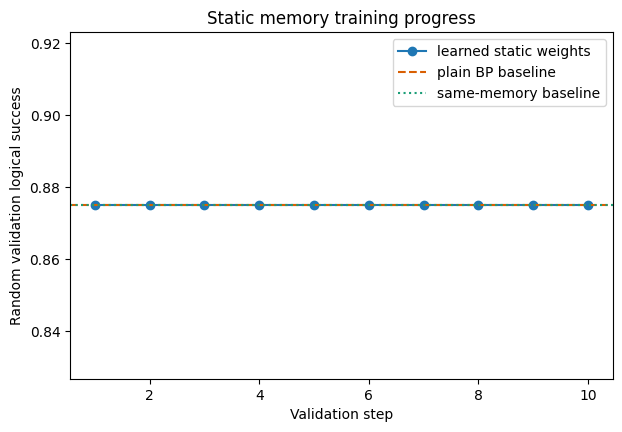

In [2]:
import matplotlib.pyplot as plt

if validation_rows:
    steps = [int(row["step"]) for row in validation_rows]
    model_rates = [float(row["random_validation_logical_success_rate"]) for row in validation_rows]
    bp_rate = float(validation_rows[0]["random_validation_bp_logical_success_rate"])
    same_mem_rate = float(validation_rows[0]["random_validation_same_mem_logical_success_rate"])
    fig, ax = plt.subplots(figsize=(7.0, 4.5))
    ax.plot(steps, model_rates, marker="o", label="learned static weights")
    ax.axhline(bp_rate, color="#d95f02", linestyle="--", label="plain BP baseline")
    ax.axhline(same_mem_rate, color="#1b9e77", linestyle=":", label="same-memory baseline")
    ax.set_xlabel("Validation step")
    ax.set_ylabel("Random validation logical success")
    ax.set_title("Static memory training progress")
    ax.legend()
    plt.show()
else:
    print(f"No validation rows found under {RUN_DIR}.")
